In [2]:
import pandas as pd

# Load each CSV and add a 'rest' column
df_random = pd.read_csv('random.csv')
df_random['rest'] = 'random'

df_stratified = pd.read_csv('stratified.csv')
df_stratified['rest'] = 'stratified'

df_bucket = pd.read_csv('bucket.csv')
df_bucket['rest'] = 'bucket'

# Concatenate all dataframes
df = pd.concat([df_random, df_stratified, df_bucket], ignore_index=True)

# Display the combined dataframe
df.head()

df.to_csv('combined_shapley_data.csv', index=False)

In [3]:
# Derivative 
df["dphi_topN"] = df.groupby("rest")["phi_topN"].diff()
df["dphi_rest"] = df.groupby("rest")["phi_rest"].diff()

# Sign
df["sign_topN"] = df["phi_topN"].apply(lambda x: 1 if x > 0 else -1 if x < 0 else 0)
df["sign_rest"] = df["phi_rest"].apply(lambda x: 1 if x > 0 else -1 if x < 0 else 0)
df

,n_rest,rest_ratio_vs_total,rest_ratio_vs_rest_pool,phi_topN,phi_rest,E_topN,E_rest_only,E_hybrid,rest,dphi_topN,dphi_rest,sign_topN,sign_rest
0,1000,0.002,0.002020,-0.306576,-1.344544,1.933686,2.971654,1.651121,random,NaN,NaN,-1,-1
1,6000,0.012,0.012121,-0.918484,-0.233780,1.933686,1.248982,1.152264,random,-0.611908,1.110765,-1,-1
2,11000,0.022,0.022222,-0.815995,0.197527,1.933686,0.920164,0.618468,random,0.102490,0.431307,-1,1
3,16000,0.032,0.032323,-0.861047,0.202760,1.933686,0.869879,0.658287,random,-0.045053,0.005233,-1,1
4,21000,0.042,0.042424,-0.937430,0.283544,1.933686,0.712712,0.653886,random,-0.076383,0.080784,-1,1
5,26000,0.052,0.052525,-0.933223,0.434897,1.933686,0.565566,0.498325,random,0.004208,0.151353,-1,1
6,31000,0.062,0.062626,-0.930951,0.328872,1.933686,0.673864,0.602079,random,0.002272,-0.106026,-1,1
7,36000,0.072,0.072727,-0.954107,0.354043,1.933686,0.625536,0.600064,random,-0.023157,0.025171,-1,1
8,41000,0.082,0.082828,-0.923022,0.434178,1.933686,0.576486,0.488844,random,0.031085,0.080135,-1,1
9,46000,0.092,0.092929,-0.937305,0.607131,1.933686,0.389250,0.330174,random,-0.014282,0.172953,-1,1


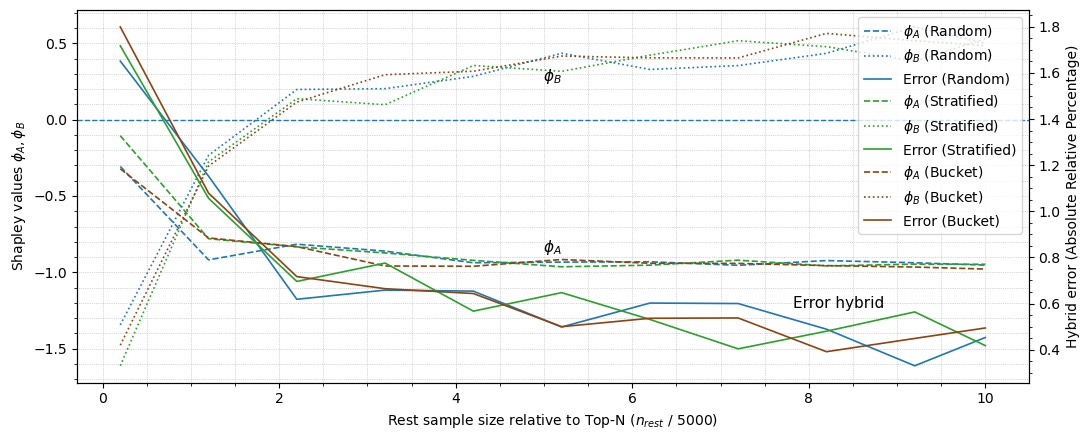

In [4]:
import matplotlib.pyplot as plt

TOPN_SIZE = 5000.0
df["rest_rel"] = df["n_rest"] / TOPN_SIZE

# Ensure deterministic order
name_map  = {"random": "Random", "stratified": "Stratified", "bucket": "Bucket"}
color_map = {"random": "tab:blue", "stratified": "tab:green", "bucket": "saddlebrown"}

method_order = ["random", "stratified", "bucket"]
available    = df["rest"].unique().tolist()
rest_methods = [m for m in method_order if m in available]

df_rel_sorted = df.sort_values(["rest", "rest_rel"])
threshold = 0.05  # when hybrid is "fixed"

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()

legend_entries = {}

for r in rest_methods:
    sub = df_rel_sorted[df_rel_sorted["rest"] == r]
    rest_cap = name_map[r]
    color = color_map[r]

    # ---- Shapley curves (left y-axis) ----
    label_phiA = rf"$\phi_A$ ({rest_cap})"
    label_phiB = rf"$\phi_B$ ({rest_cap})"

    # phi_A: fine dashed
    line_phiA, = ax1.plot(
        sub["rest_rel"], sub["phi_topN"],
        linestyle="--", linewidth=1.2, color=color, label=label_phiA
    )
    # phi_B: dotted
    line_phiB, = ax1.plot(
        sub["rest_rel"], sub["phi_rest"],
        linestyle=":", linewidth=1.2, color=color, label=label_phiB
    )
    legend_entries[label_phiA] = line_phiA
    legend_entries[label_phiB] = line_phiB

    # ---- Hybrid error (right y-axis): solid line ----
    label_err = f"Error ({rest_cap})"
    line_err, = ax2.plot(
        sub["rest_rel"], sub["E_hybrid"],
        linestyle="-", linewidth=1.2, color=color, label=label_err
    )
    legend_entries[label_err] = line_err

    # ---- Break point where E_hybrid < threshold ----
    bp = sub[sub["E_hybrid"] < threshold]
    if len(bp) > 0:
        bp_val = bp.iloc[0]["rest_rel"]
        ax1.axvline(bp_val, color=color, alpha=0.6, linestyle=":", linewidth=2)
        ax1.text(
            bp_val,
            ax1.get_ylim()[1] * 0.9,
            f"{rest_cap} break={bp_val:.2f}×TopN",
            color=color,
            rotation=90,
            va="top"
        )

# ---- Zero line for Shapley values ----
ax1.axhline(0, linestyle="--", linewidth=1)

# ---- Labels (no title) ----
ax1.set_xlabel("Rest sample size relative to Top-N ($n_{rest}$ / 5000)")
ax1.set_ylabel(r"Shapley values $\phi_A, \phi_B$")
ax2.set_ylabel("Hybrid error (Absolute Relative Percentage)")

# ---- Grid with major+minor ticks ----
ax1.minorticks_on()
ax2.minorticks_on()
ax1.grid(True, which="both", linestyle=":", linewidth=0.5)

# ---- Ordered legend: φ_A, φ_B, Error; Random, Stratified, Bucket ----
ordered_labels = []
for rest_cap in ["Random", "Stratified", "Bucket"]:
    if rest_cap in [name_map[x] for x in available]:
        ordered_labels.append(rf"$\phi_A$ ({rest_cap})")
        ordered_labels.append(rf"$\phi_B$ ({rest_cap})")
        ordered_labels.append(f"Error ({rest_cap})")

handles = [legend_entries[l] for l in ordered_labels if l in legend_entries]
ax2.legend(handles, [l for l in ordered_labels if l in legend_entries], loc="upper right")

# ---- Floating labels for groups: φ_A, φ_B, Error ----
x_min, x_max = ax1.get_xlim()
x1 = x_min + 0.50 * (x_max - x_min)
x2 = x_min + 0.50 * (x_max - x_min)
x3 = x_min + 0.80 * (x_max - x_min)

y_phiA = df_rel_sorted["phi_topN"].median()*0.9
y_phiB = df_rel_sorted["phi_rest"].median()*0.8
y_err  = df_rel_sorted["E_hybrid"].median()

ax1.text(x1, y_phiA, r"$\phi_A$", fontsize=11,
         ha="center", va="center")#, bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
ax1.text(x2, y_phiB, r"$\phi_B$", fontsize=11,
         ha="center", va="center")#, bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
ax2.text(x3, y_err, "Error hybrid", fontsize=11,
         ha="center", va="center")#, bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()


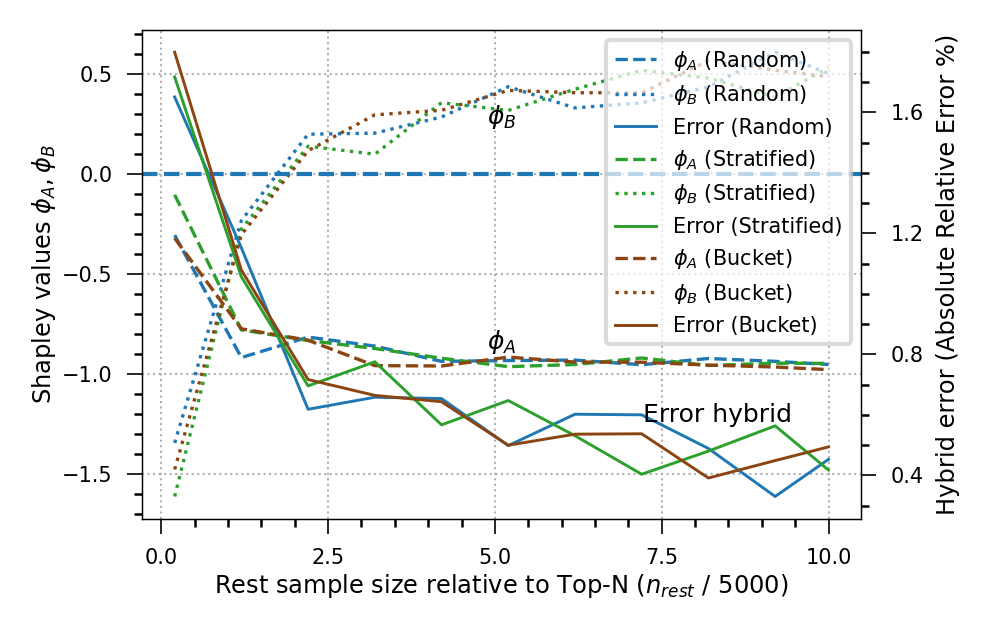

In [5]:
TOPN_SIZE = 5000.0
df["rest_rel"] = df["n_rest"] / TOPN_SIZE

# Ensure deterministic order
name_map  = {"random": "Random", "stratified": "Stratified", "bucket": "Bucket"}
color_map = {"random": "tab:blue", "stratified": "tab:green", "bucket": "saddlebrown"}

method_order = ["random", "stratified", "bucket"]
available    = df["rest"].unique().tolist()
rest_methods = [m for m in method_order if m in available]

df_rel_sorted = df.sort_values(["rest", "rest_rel"])
threshold = 0.05  # when hybrid is "fixed"

fig, ax1 = plt.subplots(figsize=(3.4, 2.2), dpi=300)
ax2 = ax1.twinx()

legend_entries = {}

for r in rest_methods:
    sub = df_rel_sorted[df_rel_sorted["rest"] == r]
    rest_cap = name_map[r]
    color = color_map[r]

    # ---- Shapley curves (left y-axis) ----
    label_phiA = rf"$\phi_A$ ({rest_cap})"
    label_phiB = rf"$\phi_B$ ({rest_cap})"

    # phi_A: fine dashed
    line_phiA, = ax1.plot(
        sub["rest_rel"], sub["phi_topN"],
        linestyle="--", linewidth=0.8, color=color, label=label_phiA
    )
    # phi_B: dotted
    line_phiB, = ax1.plot(
        sub["rest_rel"], sub["phi_rest"],
        linestyle=":", linewidth=0.8, color=color, label=label_phiB
    )
    legend_entries[label_phiA] = line_phiA
    legend_entries[label_phiB] = line_phiB

    # ---- Hybrid error (right y-axis): solid line ----
    label_err = f"Error ({rest_cap})"
    line_err, = ax2.plot(
        sub["rest_rel"], sub["E_hybrid"],
        linestyle="-", linewidth=0.7, color=color, label=label_err
    )
    legend_entries[label_err] = line_err

    # ---- Break point where E_hybrid < threshold ----
    bp = sub[sub["E_hybrid"] < threshold]
    if len(bp) > 0:
        bp_val = bp.iloc[0]["rest_rel"]
        ax1.axvline(bp_val, color=color, alpha=0.6, linestyle=":", linewidth=2)
        ax1.text(
            bp_val,
            ax1.get_ylim()[1] * 0.9,
            f"{rest_cap} break={bp_val:.2f}×TopN",
            color=color,
            rotation=90,
            va="top"
        )

# ---- Zero line for Shapley values ----
ax1.axhline(0, linestyle="--", linewidth=1)

# ---- Labels (no title) ----
# ax1.set_xlabel("Rest sample size relative to Top-N ($n_{rest}$ / 5000)")
# ax1.set_ylabel(r"Shapley values $\phi_A, \phi_B$")
# ax2.set_ylabel("Hybrid error (Absolute Relative Percentage)")
label_fontsize = 5.8
ax1.set_xlabel(
    "Rest sample size relative to Top-N ($n_{rest}$ / 5000)",
    fontsize=label_fontsize,
    labelpad=1
)

ax1.set_ylabel(
    r"Shapley values $\phi_A, \phi_B$",
    fontsize=label_fontsize,
    labelpad=1
)

ax2.set_ylabel(
    "Hybrid error (Absolute Relative Error %)",
    fontsize=label_fontsize,
    labelpad=3
)

ax1.tick_params(axis="both", labelsize=5) 
ax2.tick_params(axis="both", labelsize=5) 

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
    ax.tick_params(width=0.4)
    
ax1.xaxis.set_major_locator(plt.MaxNLocator(5))
ax1.yaxis.set_major_locator(plt.MaxNLocator(5))
ax2.yaxis.set_major_locator(plt.MaxNLocator(5))

# ---- Grid with major+minor ticks ----
ax1.minorticks_on()
ax2.minorticks_on()
# ax1.grid(True, which="both", linestyle=":", linewidth=0.5)

ax1.grid(True, which="major", linestyle=":", linewidth=0.5)

# ---- Ordered legend: φ_A, φ_B, Error; Random, Stratified, Bucket ----
ordered_labels = []
for rest_cap in ["Random", "Stratified", "Bucket"]:
    if rest_cap in [name_map[x] for x in available]:
        ordered_labels.append(rf"$\phi_A$ ({rest_cap})")
        ordered_labels.append(rf"$\phi_B$ ({rest_cap})")
        ordered_labels.append(f"Error ({rest_cap})")

handles = [legend_entries[l] for l in ordered_labels if l in legend_entries]
ax2.legend(handles, [l for l in ordered_labels if l in legend_entries], loc="upper right", fontsize=5, framealpha=0.7)

# ---- Floating labels for groups: φ_A, φ_B, Error ----
x_min, x_max = ax1.get_xlim()
x1 = x_min + 0.50 * (x_max - x_min)
x2 = x_min + 0.50 * (x_max - x_min)
x3 = x_min + 0.80 * (x_max - x_min)

y_phiA = df_rel_sorted["phi_topN"].median()*0.9
y_phiB = df_rel_sorted["phi_rest"].median()*0.8
y_err  = df_rel_sorted["E_hybrid"].median()

ax1.text(x1, y_phiA, r"$\phi_A$", fontsize=6,
         ha="center", va="center")#, bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
ax1.text(x2, y_phiB, r"$\phi_B$", fontsize=6,
         ha="center", va="center")#, bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
ax2.text(x3, y_err, "Error hybrid", fontsize=6,
         ha="center", va="center")#, bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

plt.tight_layout()
fig.savefig("/Users/viewv/lsweb_paper/figs/shapley/shapley.pdf", bbox_inches="tight", pad_inches=0)
plt.show()
